# AE 696, Lab 1
## Python Warm-Up, Optimization, and First RL Interaction

**Course:** AE 696, Reinforcement Learning with AI Applications in Engineering  
**Instructor:** Dr. Jun Chen

### Learning Goals
By the end of this lab, you should be able to:
1. Use **NumPy** for vectorized computation.
2. Implement **gradient descent** for a simple optimization problem.
3. Visualize optimization trajectories with **Matplotlib**.
4. Interact with a **Gymnasium** environment.
5. Record and analyze **episode returns** for a random agent.

### Submission
Submit:
- This completed notebook (`.ipynb`)
- Any required plots embedded in the notebook
- Short written answers in the markdown cells provided

### Notes
- Complete all **TODO** sections.
- Keep your code clear and well commented.
- You may discuss ideas with classmates, but your submitted work must reflect your own understanding.


## Part 0, Setup

Run the cell below to import the required packages.

If `gymnasium` is not installed on your machine, install it first using pip. In a local terminal, that would typically be:

```bash
pip install gymnasium
```

For this lab, we will use `CartPole-v1`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print("Libraries imported successfully.")

Libraries imported successfully.


## Part 1, NumPy Warm-Up

In reinforcement learning, we constantly work with vectors, matrices, and arrays.  
This section is a quick warm-up using NumPy.


### Task 1.1
Create the following objects:
- A vector `x = [1, 2, 3]`
- A matrix

\[
A = \begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix}
\]

Then:
1. Print `x`
2. Print `A`
3. Compute `A @ x[:2]`


In [ ]:
# TODO: Create x and A, then print them and compute A @ x[:2]

x = np.array([1, 2, 3])

A = np.array([
                [1,2],
                [3,4]
                ])

print(f"x array: \n{x}")
print(f"A array: \n{A}")

result = A @ x[:2]
print(f"Compute A @ x[:2]: \n{result}")

x array: 
[1 2 3]
A array: 
[[1 2]
 [3 4]]
Compute A @ x[:2]: 
[ 5 11]


### Task 1.2
Use NumPy vectorized operations to compute:
- `2*x`
- `x + 5`

Then print the results.

Why is vectorization useful in scientific computing and RL?


In [ ]:
# TODO: Compute and print 2*x and x+5

print(f"2 * x = {2*x}")
print(f"x + 5 = {x+5}")


2 * x = [2 4 6]
x + 5 = [6 7 8]


### Short Response 1
Write 1 to 2 sentences: Why is vectorization useful in RL and numerical computing?

**Your response:**  

Vectorization is useful in scientific computing and RL because 
it is a fast, and efficient computational tool in a field that 
requires millions of computations for complex modeling.
By using vectorization, we save computer RAM, long term storage,
and we decrease time costs. Compared to sequential loops, 
vectorization has high efficiency, GPU utilization, and allows
for faster training times.

## Part 2, Gradient Descent on a Convex Function

We now implement gradient descent for a simple convex optimization problem.

Consider the function

\[
f(x, y) = x^2 + y^2
\]

Its gradient is

\[
\nabla f(x, y) = [2x, 2y]^T
\]

This function has a global minimum at \((0,0)\).


### Task 2.1
Complete the function definitions below for:
- `f(x, y)`
- `grad_f(x, y)`


In [11]:
import numpy as np
def f(x, y):
    # TODO: return the function value
    fResult = x**2 + y**2
    return fResult

def grad_f(x, y):
    # TODO: return the gradient as a NumPy array [df/dx, df/dy]
    gradResult = np.array([2*x, 2*y])
    return gradResult


### Task 2.2
Implement gradient descent.

Use:
- Initial point: \((x_0, y_0) = (4.0, -3.0)\)
- Learning rate: `alpha = 0.1`
- Number of iterations: `25`

Store the full trajectory of points in a list or array so you can plot it later.


In [67]:
# TODO: Implement gradient descent and store the trajectory

alpha = 0.1
num_iters = 25
x, y = 4.0, -3.0

trajectory = []

# Your code here
xyArr = np.array([x, y])

def gradientDescent2D(iters, initXY, alpha):
    """
    2D gradient descent function.
    In: 
        iters (int)   - How many runs
        initXY (2,)  - initial values
        alpha (int)   - learning rate
    Out:
        trajectory (iters x 2) - array list of the descent
    """

    trajectory = []
    currentXY = initXY.copy()

    for i in range(iters):
        x_g, y_g = grad_f(currentXY[0], currentXY[1])
        xyGradArr = np.array([x_g, y_g])

        currentXY = currentXY - alpha * xyGradArr
        trajectory.append(currentXY.copy())
        # print(i, currentXY, xyGradArr)

    return np.array(trajectory)


trajectory = gradientDescent2D(num_iters, xyArr, alpha)


print(trajectory)


[[ 3.2        -2.4       ]
 [ 2.56       -1.92      ]
 [ 2.048      -1.536     ]
 [ 1.6384     -1.2288    ]
 [ 1.31072    -0.98304   ]
 [ 1.048576   -0.786432  ]
 [ 0.8388608  -0.6291456 ]
 [ 0.67108864 -0.50331648]
 [ 0.53687091 -0.40265318]
 [ 0.42949673 -0.32212255]
 [ 0.34359738 -0.25769804]
 [ 0.27487791 -0.20615843]
 [ 0.21990233 -0.16492674]
 [ 0.17592186 -0.1319414 ]
 [ 0.14073749 -0.10555312]
 [ 0.11258999 -0.08444249]
 [ 0.09007199 -0.06755399]
 [ 0.07205759 -0.0540432 ]
 [ 0.05764608 -0.04323456]
 [ 0.04611686 -0.03458765]
 [ 0.03689349 -0.02767012]
 [ 0.02951479 -0.02213609]
 [ 0.02361183 -0.01770887]
 [ 0.01888947 -0.0141671 ]
 [ 0.01511157 -0.01133368]]


### Task 2.3
Print:
- Final point
- Final function value


In [ ]:
# TODO: Print final point and final function value

# Your code here

print(f"The final point in the trajectory is {trajectory[-1,:]}")

print(f"The final function value in grad_f() is {xyGradArr}")




The final point in the trajectory is [ 0.01511157 -0.01133368]
The final function value in grad_f() is [ 0.03777893 -0.0283342 ]


### Task 2.4
Create a contour plot of the function and overlay the optimization trajectory.

Helpful steps:
1. Create a grid using `np.linspace`
2. Evaluate `f` on the grid
3. Use `plt.contour(...)`
4. Plot the stored trajectory points on top


Text(0, 0.5, 'y')

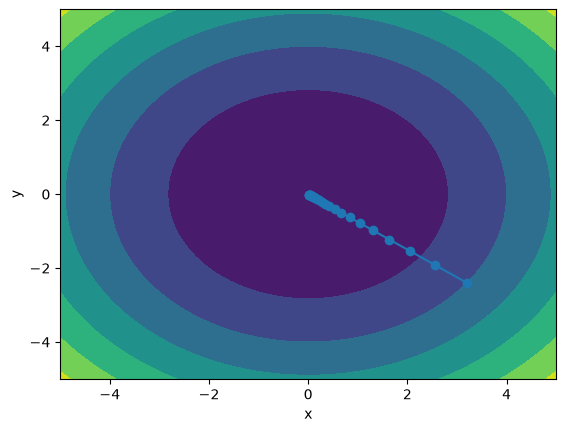

In [66]:
# TODO: Plot contour lines and the gradient descent trajectory

# Suggested grid:
xs = np.linspace(-5, 5, 200)
ys = np.linspace(-5, 5, 200)

# Your code here
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)
plt.contourf(X, Y, Z)

plt.plot(trajectory[:, 0], trajectory[:, 1], marker="o")
plt.xlabel("x")
plt.ylabel("y")
#plt.show()

### Short Response 2
Write 2 to 3 sentences:
1. Did the algorithm converge?
2. What role did the learning rate play?
3. What do you expect if the learning rate becomes much larger?

**Your response:**  
The values converged with the given alpha = 0.1. When I adjusted it to 1.0, x switched from 4 to -4, and when at 0.01, it was only half way to converging, so the value of alpha drastically changes how the results converge. If the learning rate grows, it will continue to worsen and the values nearly end up diverging they get so large.


## Part 3, Exploring the Effect of Learning Rate

Now test how the learning rate affects convergence.

Try at least three values:
- `alpha = 0.01`
- `alpha = 0.1`
- `alpha = 0.8`

For each one:
- Run gradient descent
- Record the final point
- Record whether the method seemed stable


In [103]:
# TODO: Compare multiple learning rates

learning_rates = [0.01, 0.1, 0.8]

# You may write a helper function if you want.
# Your code here
trajectories = []
finalTrajs = []

for alpha in learning_rates:
    trajectory = gradientDescent2D(25, xyArr, alpha)
    trajectories.append(trajectory)

# use [0]-[2] for each alpha
# print(trajectories[2])

for trajectory in trajectories:
    finalTrajs.append(trajectory[-1, :])

finalTrajs = np.vstack(finalTrajs)

print(f"The Final Trajectory Points for each alpha are:\n{finalTrajs}")
print(f"alpha = {learning_rates[0]} converges too slow. Stable \n"
      f"alpha = {learning_rates[1]} converges smoothly. Stable.\n"
      f"alpha = {learning_rates[2]} fails to converge. Unstable.")


The Final Trajectory Points for each alpha are:
[[ 2.41385892e+00 -1.81039419e+00]
 [ 1.51115727e-02 -1.13336796e-02]
 [-1.13721152e-05  8.52908641e-06]]
alpha = 0.01 converges too slow. Stable 
alpha = 0.1 converges smoothly. Stable.
alpha = 0.8 fails to converge. Unstable.


### Short Response 3
Write 2 to 4 sentences comparing the behavior for different learning rates.

**Your response:**  
If the learning rate is too small, it is still stable, however the loss decreases steadily and in too few of increments. This requires too many iterations to reach the minimum. A large learning rate us unstable, because the loss fluctuates wildly, bouncing back and forth, and/or diverging. The perfect learning rate reaches the minimum in an appropriate numer of iterations and neatly converges.

## Part 4, Gradient Descent on a Non-Convex Function

Deep learning and deep RL are generally **non-convex**, so initialization can matter.

Consider the function

\[
g(x) = x^4 - 3x^3 + 2
\]

Its derivative is

\[
g'(x) = 4x^3 - 9x^2
\]


### Task 4.1
Complete the function definitions below.


In [ ]:
def g(x):
    # TODO
    pass

def grad_g(x):
    # TODO
    pass


### Task 4.2
Run gradient descent on `g(x)` using:
- Learning rate `alpha = 0.01`
- Number of iterations `100`

Use **at least three different initial points**, for example:
- `x0 = -1.0`
- `x0 = 0.5`
- `x0 = 3.0`

Store the trajectories and compare the final values.


In [ ]:
# TODO: Run gradient descent from multiple initial points on g(x)

alpha = 0.01
num_iters = 100
initial_points = [-1.0, 0.5, 3.0]

# Your code here


### Task 4.3
Plot the function `g(x)` and overlay the trajectories from the different starting points.


In [ ]:
# TODO: Plot g(x) and overlay trajectories from different initializations

# Your code here


### Short Response 4
Write 2 to 4 sentences:
1. Did different initializations lead to different outcomes?
2. Why is this important for deep learning and deep RL?

**Your response:**  
TODO


## Part 5, First RL Interaction with Gymnasium

We now move from optimization to a simple RL environment.

We will use **CartPole-v1**, a classic control task:
- The environment gives observations about the cart and pole.
- The action space is discrete.
- A reward is received at each time step while the pole remains upright.

For now, we will use a **random agent** that chooses actions uniformly at random.


### Task 5.1
Create the environment and inspect:
- Observation space
- Action space


In [ ]:
# TODO: Create the CartPole environment and print the observation/action spaces

# Your code here


### Task 5.2
Reset the environment and print the initial observation.

Then answer:
- What information might this observation contain?


In [ ]:
# TODO: Reset the environment and print the initial observation

# Your code here


### Short Response 5
What information do you think the CartPole observation contains?

**Your response:**  
TODO


### Task 5.3
Run **one episode** using a random policy:
1. Reset the environment
2. Repeatedly sample a random action
3. Apply `env.step(action)`
4. Accumulate the total reward
5. Stop when the episode ends

Be careful: in Gymnasium, an episode ends when either:
- `done` is `True`, or
- `truncated` is `True`


In [ ]:
# TODO: Run one random episode and compute the total reward

# Your code here


### Task 5.4
Run **20 episodes** using the same random policy.
For each episode:
- Record the total return
- Store it in a list called `returns`

Then print the list and the average return.


In [ ]:
# TODO: Run 20 random episodes and store returns

# Your code here


### Task 5.5
Create a plot of episode return versus episode number.


In [ ]:
# TODO: Plot episode return versus episode number

# Your code here


### Short Response 6
Write 2 to 4 sentences:
1. How well did the random agent perform?
2. Why does a random policy perform poorly on this task?
3. What would a learning algorithm need to improve performance?

**Your response:**  
TODO


## Part 6, Reflection

Answer the following briefly.

### Reflection Questions
1. What was the main connection between optimization and RL in this lab?
2. What was the most important thing you learned from the CartPole experiment?
3. What part of the lab was most challenging?

**Your responses:**  
1. TODO  
2. TODO  
3. TODO


## Optional Challenge

Try a very simple hand-designed policy for CartPole instead of a random policy.

For example, use the pole angle (often one component of the observation) to pick an action:
- If the pole leans left, push left
- If the pole leans right, push right

You may need to inspect the observation vector carefully.

Then compare:
- Random policy return
- Hand-designed policy return

Briefly comment on which one performs better and why.


In [ ]:
# Optional Challenge
# Try a simple hand-designed policy and compare against the random agent.

# Your code here


## Final Checklist

Before submitting, make sure:
- All TODO sections are completed
- All plots are visible in the notebook
- All short responses are answered
- Your code runs from top to bottom without errors
